Customer Segmentation

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [26]:
data = pd.read_csv("/content/customer_segmentation_data.csv")


Inspect The Data

In [27]:
data.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [28]:
data.tail()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
53498,44809,35,Female,Divorced,Associate Degree,Andaman and Nicobar Islands,Salesperson,120850,policy3,01-01-2019,Mobile App,policy1,586401,4404,Family,In-Person Meeting,Phone,Afternoon,German,Segment5
53499,65485,61,Male,Single,Doctorate,Himachal Pradesh,Entrepreneur,122309,policy5,5/18/2021,Mobile App,policy4,637733,1285,Group,Text,Mail,Afternoon,German,Segment1
53500,26213,25,Male,Divorced,Doctorate,Assam,Teacher,49258,policy2,11/27/2018,In-Person,policy1,631057,4407,Individual,Text,Text,Weekends,French,Segment4
53501,63136,42,Male,Married,Doctorate,Andhra Pradesh,Artist,66301,policy4,06-04-2021,In-Person,policy1,730385,4482,Business,Mail,Phone,Morning,French,Segment5
53502,62125,20,Male,Divorced,Doctorate,Daman and Diu,Salesperson,136632,policy2,10/14/2022,Phone,policy1,743262,4499,Group,Text,In-Person Meeting,Evening,German,Segment2


In [29]:
data.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Marital Status,0
Education Level,0
Geographic Information,0
Occupation,0
Income Level,0
Behavioral Data,0
Purchase History,0


In [30]:
data.duplicated().sum()

np.int64(0)

In [31]:
data.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

Understand The Data

In [33]:
# which customer spent most
data[data["Coverage Amount"]==data["Coverage Amount"].max()]

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
966,55575,40,Male,Married,Doctorate,Arunachal Pradesh,Nurse,84231,policy2,05-11-2023,Email,policy1,1000000,4609,Group,Phone,In-Person Meeting,Anytime,English,Segment2
2352,83658,47,Male,Divorced,High School Diploma,Maharashtra,Salesperson,84166,policy2,12-11-2018,Chat,policy5,1000000,2010,Family,Email,In-Person Meeting,Anytime,French,Segment4
2650,15469,31,Male,Married,High School Diploma,Himachal Pradesh,Entrepreneur,69712,policy3,10/28/2022,Email,policy1,1000000,2991,Family,Mail,Email,Morning,German,Segment2
7993,73997,33,Female,Divorced,Associate Degree,Daman and Diu,Artist,61224,policy3,8/23/2021,Phone,policy4,1000000,2296,Group,Email,Email,Evening,Mandarin,Segment5
12871,1598,43,Female,Widowed,Master's Degree,Uttarakhand,Artist,145090,policy3,01-10-2023,Chat,policy1,1000000,3348,Group,Text,Mail,Weekends,French,Segment1
15525,77369,36,Male,Widowed,Doctorate,Sikkim,Manager,138526,policy4,10-02-2018,Phone,policy3,1000000,3256,Group,In-Person Meeting,Mail,Afternoon,French,Segment1
17794,40622,55,Female,Widowed,High School Diploma,Kerala,Engineer,50143,policy2,1/13/2022,Chat,policy3,1000000,1572,Group,In-Person Meeting,In-Person Meeting,Morning,French,Segment2
18323,23797,47,Female,Married,High School Diploma,Karnataka,Salesperson,52639,policy3,6/14/2023,Mobile App,policy5,1000000,2185,Group,Mail,Text,Morning,English,Segment1
18662,55414,18,Female,Single,High School Diploma,Mizoram,Engineer,109585,policy1,10-03-2023,Phone,policy5,1000000,4492,Family,Phone,Text,Weekends,German,Segment1
18919,98084,33,Male,Divorced,High School Diploma,Punjab,Artist,36009,policy5,06-04-2019,Email,policy3,1000000,1862,Business,In-Person Meeting,Mail,Evening,Mandarin,Segment4


In [35]:
# Which customers have high income
data[data["Income Level"] == data["Income Level"].max()]


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
4575,88202,57,Male,Divorced,Bachelor's Degree,Telangana,Salesperson,149999,policy5,7/18/2019,Phone,policy2,769510,647,Individual,In-Person Meeting,Text,Weekends,Mandarin,Segment4
4594,15638,44,Male,Widowed,Associate Degree,Goa,Lawyer,149999,policy2,6/18/2018,Mobile App,policy2,326996,4546,Business,Mail,Phone,Weekends,English,Segment1
5507,1459,42,Female,Separated,Doctorate,Bihar,Artist,149999,policy5,07-01-2021,In-Person,policy1,801838,1120,Family,Email,Email,Anytime,French,Segment3
6813,73637,31,Female,Single,High School Diploma,Madhya Pradesh,Engineer,149999,policy2,11/20/2019,In-Person,policy3,803421,3024,Business,Text,Mail,Anytime,German,Segment1
13380,86070,21,Male,Married,High School Diploma,Mizoram,Doctor,149999,policy1,9/22/2022,Chat,policy3,530961,2370,Individual,Email,Mail,Evening,German,Segment4
14851,63861,33,Male,Separated,Associate Degree,Uttarakhand,Engineer,149999,policy3,2/19/2021,Email,policy2,778697,1574,Group,In-Person Meeting,Email,Evening,English,Segment2
17836,21134,18,Female,Separated,Associate Degree,Uttarakhand,Doctor,149999,policy1,8/21/2019,In-Person,policy4,314023,4275,Business,Email,Email,Evening,Spanish,Segment1
18320,91013,31,Female,Divorced,Doctorate,Chandigarh,Entrepreneur,149999,policy4,10-11-2019,Phone,policy2,266171,1941,Group,In-Person Meeting,Phone,Evening,German,Segment4
18852,23526,37,Female,Widowed,Doctorate,Chhattisgarh,Entrepreneur,149999,policy3,4/19/2022,Chat,policy2,657063,3611,Family,Phone,Email,Morning,German,Segment5
21867,96537,46,Male,Separated,Associate Degree,Mizoram,Artist,149999,policy5,06-08-2023,Phone,policy1,323561,4370,Group,Text,In-Person Meeting,Afternoon,French,Segment2


In [36]:
#Which customers spend very little
data[data["Coverage Amount"] == data["Coverage Amount"].min()]

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
97,22602,23,Male,Married,Associate Degree,Delhi,Lawyer,25667,policy4,1/17/2022,Chat,policy5,50001,2909,Business,Text,In-Person Meeting,Weekends,English,Segment4
3068,76192,63,Female,Married,Bachelor's Degree,Gujarat,Doctor,122979,policy3,09-06-2018,Mobile App,policy5,50001,4017,Group,Text,Email,Morning,Spanish,Segment2
3232,31800,57,Female,Separated,Bachelor's Degree,Assam,Teacher,126074,policy5,10/28/2018,Email,policy1,50001,1061,Individual,Email,Phone,Weekends,German,Segment5
4482,54157,46,Female,Separated,Bachelor's Degree,Punjab,Nurse,109031,policy5,7/18/2019,Phone,policy3,50001,4467,Individual,Phone,Email,Evening,German,Segment2
5387,95073,26,Male,Widowed,Bachelor's Degree,Delhi,Entrepreneur,54207,policy3,1/27/2018,Mobile App,policy4,50001,1711,Group,Text,Text,Evening,Mandarin,Segment2
5715,67387,49,Female,Widowed,Associate Degree,Daman and Diu,Lawyer,74422,policy2,11/18/2022,In-Person,policy1,50001,1590,Individual,In-Person Meeting,In-Person Meeting,Anytime,French,Segment2
5869,85055,55,Female,Married,Bachelor's Degree,Andaman and Nicobar Islands,Nurse,144574,policy4,2/18/2020,Mobile App,policy4,50001,1231,Family,Phone,Phone,Morning,English,Segment4
7723,82365,33,Female,Married,Master's Degree,Haryana,Lawyer,91089,policy3,02-06-2021,In-Person,policy5,50001,824,Family,Phone,In-Person Meeting,Afternoon,German,Segment2
8196,64103,69,Female,Married,High School Diploma,Himachal Pradesh,Teacher,149247,policy4,02-04-2022,Email,policy5,50001,3206,Family,Mail,Email,Anytime,Spanish,Segment4
9799,73360,22,Female,Separated,Doctorate,Daman and Diu,Entrepreneur,24118,policy5,11/14/2023,Mobile App,policy5,50001,3514,Business,Phone,Mail,Weekends,German,Segment2


Check The Pattern

In [38]:
# Do high-income customer buy higher coverage?
data[["Income Level", "Coverage Amount"]].corr()


,Income Level,Coverage Amount
Income Level,1.000000,-0.018024
Coverage Amount,-0.018024,1.000000


In [39]:
# Does age affect premium amount?
data[['Age', 'Premium Amount']].corr()

,Age,Premium Amount
Age,1.000000,0.003665
Premium Amount,0.003665,1.000000


In [40]:
# Which occupation earns the most?
data.groupby('Occupation')['Income Level'].mean()


,Income Level
Occupation,
Artist,84224.489764
Doctor,82862.251929
Engineer,81515.959677
Entrepreneur,82519.286016
Lawyer,82671.421645
Manager,81889.955368
Nurse,83731.283123
Salesperson,83378.892537
Teacher,82174.043176


In [41]:
# Which policy type is most common?
data['Policy Type'].value_counts()

,count
Policy Type,
Group,18255
Business,13986
Family,12424
Individual,8838


In [42]:
# What makes Segment1 different from Segment2?
data.groupby('Segmentation Group')[['Age','Income Level','Coverage Amount','Premium Amount']].mean()


,Age,Income Level,Coverage Amount,Premium Amount
Segmentation Group,,,,
Segment1,43.359092,82911.536335,492677.595992,2965.523437
Segment2,44.360514,82431.974567,480677.980248,3013.880703
Segment3,44.063598,84582.656786,498189.902986,2995.951277
Segment4,43.826963,81678.547259,492392.203556,3058.089679
Segment5,44.725744,82539.892315,498678.747925,3061.397467


Prepare Data for Segmentation

In [43]:
features = data[['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']]

Scale The Data

In [44]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Find the Best Number of Clusters

In [51]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

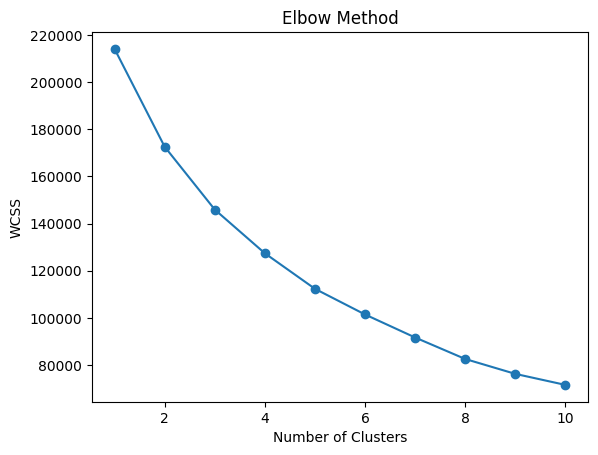

In [60]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Apply K-Means

In [53]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [54]:
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [71]:
cluster_names = {
    0: "High-Income Professionals",
    1: "Budget-Conscious Customers",
    2: "Value-Seeking Customers",
    3: "Senior Premium Customers"
}

data['Cluster_Name'] = data['Cluster'].map(cluster_names)

Analyze the Clusters

In [72]:
score = silhouette_score(scaled_features, data['Cluster'])
print(score)

0.19098004501129476


In [73]:
data['Cluster'].value_counts()

,count
Cluster,
2,13577
3,13536
1,13228
0,13162


In [74]:
data['Cluster']

,Cluster
0,1
1,2
2,1
3,1
4,2
...,...
53498,0
53499,2
53500,1
53501,1


In [75]:
data.groupby('Cluster')[['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']].mean()

,Age,Income Level,Coverage Amount,Premium Amount
Cluster,,,,
0,33.599681,121729.022793,462271.731576,3151.566555
1,35.308210,52435.529483,498412.998261,3887.948065
2,45.481844,66567.815865,515044.475952,1443.018266
3,61.677748,90776.288268,493821.178044,3640.262781


In [76]:
data.groupby('Cluster')['Occupation'].value_counts()

Cluster  Occupation  
0        Salesperson     1957
         Entrepreneur    1599
         Artist          1499
         Manager         1440
         Engineer        1421
         Teacher         1413
         Lawyer          1366
         Doctor          1361
         Nurse           1106
1        Salesperson     1910
         Entrepreneur    1731
         Teacher         1528
         Manager         1527
         Lawyer          1429
         Engineer        1400
         Doctor          1345
         Artist          1293
         Nurse           1065
2        Salesperson     1903
         Entrepreneur    1590
         Engineer        1545
         Lawyer          1544
         Doctor          1476
         Teacher         1459
         Artist          1428
         Manager         1420
         Nurse           1212
3        Salesperson     2149
         Entrepreneur    1716
         Teacher         1506
         Artist          1446
         Lawyer          1436
         Manager         1416
         Doctor          1391
         Engineer        1338
         Nurse           1138
Name: count, dtype: int64

In [77]:
data.groupby('Cluster')['Preferred Communication Channel'].value_counts()

Cluster  Preferred Communication Channel
0        In-Person Meeting                  3494
         Phone                              2897
         Mail                               2623
         Email                              2104
         Text                               2044
1        In-Person Meeting                  3680
         Phone                              2856
         Mail                               2569
         Text                               2089
         Email                              2034
2        In-Person Meeting                  3459
         Phone                              2985
         Mail                               2745
         Email                              2395
         Text                               1993
3        In-Person Meeting                  3678
         Phone                              3134
         Mail                               2492
         Email                              2270
         Text                               1962
Name: count, dtype: int64

Visualize the clusters

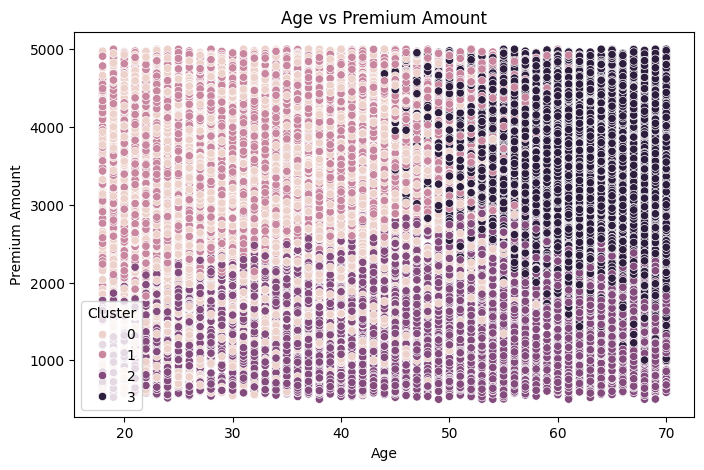

In [78]:
# Age VS Premium Amount

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Premium Amount',
    hue='Cluster',
    data=data
)

plt.title('Age vs Premium Amount')
plt.show()

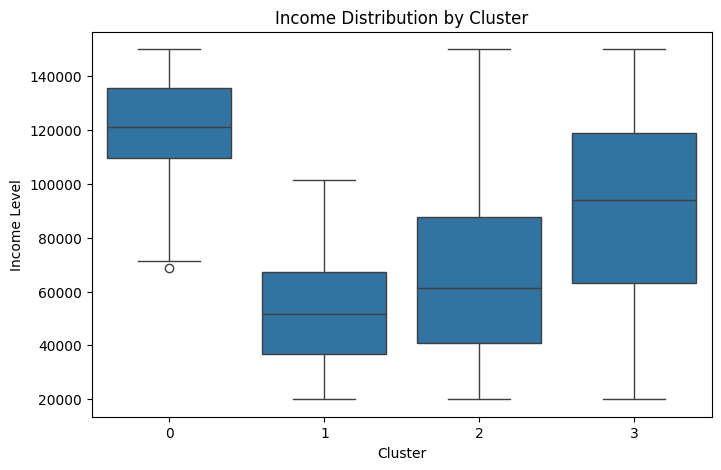

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='Income Level',
    data=data
)

plt.title('Income Distribution by Cluster')
plt.show()

<Axes: xlabel='Income Level', ylabel='Coverage Amount'>

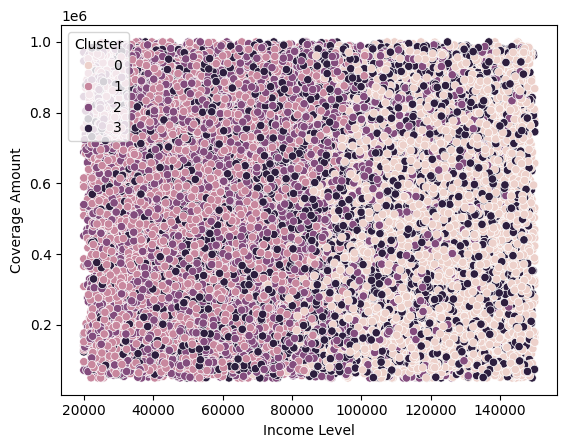

In [65]:
# Coverage Amount VS Income Level
sns.scatterplot(
    x='Income Level',
    y='Coverage Amount',
    hue='Cluster',
    data=data
)

<Axes: xlabel='Income Level', ylabel='Age'>

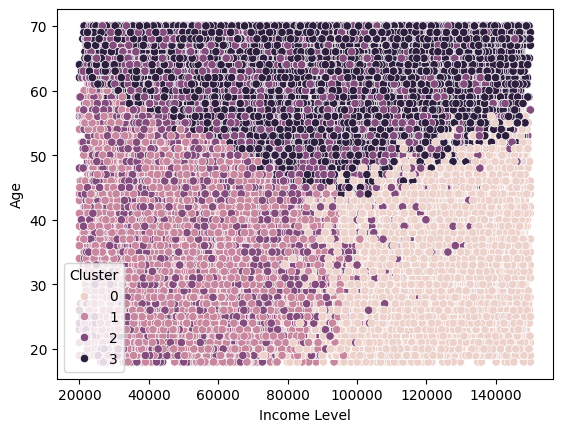

In [66]:
#Age vs Income Level


sns.scatterplot(
    x='Income Level',
    y='Age',
    hue='Cluster',
    data=data
)

<Axes: xlabel='Premium Amount', ylabel='Coverage Amount'>

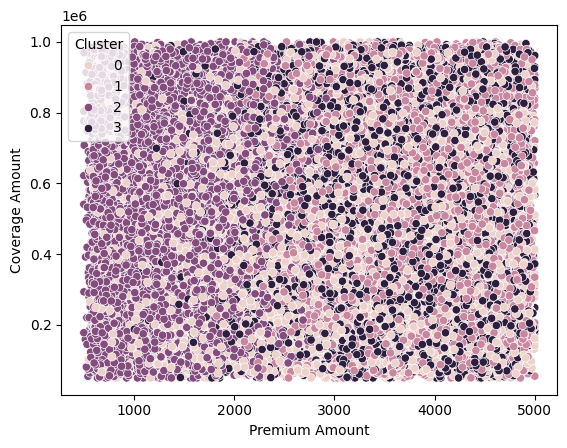

In [67]:
# Premium Amount vs Coverage Amount


sns.scatterplot(
    x='Premium Amount',
    y='Coverage Amount',
    hue='Cluster',
    data=data
)
